In [ ]:
!pip install pyspark


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Online Retail.csv to Online Retail.csv


In [ ]:
import os

os.listdir()

['.config', 'Online Retail.csv', 'sample_data']

In [ ]:
import pandas as pd

df_pd = pd.read_excel("Online Retail.csv")

df_pd.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
# Convert pandas dataframe to PySpark dataframe
df = spark.createDataFrame(df_pd)

# Dataset ki first 5 rows dekho
df.show(5)

# Schema check karo
df.printSchema()

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|2010-12-01 08:26:00|     2.55|   17850.0|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|2010-12-01 08:26:00|     3.39|   17850.0|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|2010-12-01 08:26:00|     2.75|   17850.0|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|2010-12-01 08:26:00|     3.39|   17850.0|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|2010-12-01 08:26:00|     3.39|   17850.0|United Kingdom|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
only showing top 5 rows
root

In [ ]:
print("Total Rows:", df.count())
print("Total Columns:", len(df.columns))

Total Rows: 541909
Total Columns: 8


In [ ]:
from pyspark.sql.functions import col, sum

# Missing values count
missing_values = df.select(
    [sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]
)

missing_values.show()

+---------+---------+-----------+--------+-----------+---------+----------+-------+
|InvoiceNo|StockCode|Description|Quantity|InvoiceDate|UnitPrice|CustomerID|Country|
+---------+---------+-----------+--------+-----------+---------+----------+-------+
|        0|        0|          0|       0|          0|        0|         0|      0|
+---------+---------+-----------+--------+-----------+---------+----------+-------+



In [ ]:
# Duplicate rows check
print("Duplicate Rows:", df.count() - df.dropDuplicates().count())

Duplicate Rows: 5268


In [ ]:
# Remove duplicate rows
df_clean = df.dropDuplicates()

# Check new row count
print("Rows after removing duplicates:", df_clean.count())

Rows after removing duplicates: 536641


In [ ]:
df_clean.printSchema()

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: long (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: double (nullable = true)
 |-- Country: string (nullable = true)



In [ ]:
from pyspark.sql.functions import col

# Negative quantity check
print("Negative Quantity:")
df_clean.filter(col("Quantity") < 0).count()

# Negative UnitPrice check
print("Negative UnitPrice:")
df_clean.filter(col("UnitPrice") < 0).count()

Negative Quantity:
Negative UnitPrice:


2

In [ ]:
from pyspark.sql.functions import col

# Remove invalid UnitPrice records
df_clean = df_clean.filter(col("UnitPrice") > 0)

# Check count after cleaning
print("Rows after cleaning:", df_clean.count())

Rows after cleaning: 534129


In [ ]:
from pyspark.sql.functions import col

# Create TotalSales column
df_clean = df_clean.withColumn(
    "TotalSales",
    col("Quantity") * col("UnitPrice")
)

# Show data
df_clean.show(5)

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+-----------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|       TotalSales|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+-----------------+
|   536365|    71053| WHITE METAL LANTERN|       6|2010-12-01 08:26:00|     3.39|   17850.0|United Kingdom|            20.34|
|   536373|   84029G|KNITTED UNION FLA...|       6|2010-12-01 09:02:00|     3.39|   17850.0|United Kingdom|            20.34|
|   536387|    79321|       CHILLI LIGHTS|     192|2010-12-01 09:58:00|     3.82|   16029.0|United Kingdom|733.4399999999999|
|   536401|    21744|SNOWFLAKE PORTABL...|       2|2010-12-01 11:21:00|     2.95|   15862.0|United Kingdom|              5.9|
|   536420|    22113|GREY HEART HOT WA...|       4|2010-12-01 12:03:00|     3.75|   16583.0|United Kingdom|           

In [ ]:
from pyspark.sql.functions import sum, desc

# Country wise total sales
country_sales = df_clean.groupBy("Country") \
    .agg(sum("TotalSales").alias("Total_Revenue")) \
    .orderBy(desc("Total_Revenue"))

# Top 10 countries
country_sales.show(10)

+--------------+------------------+
|       Country|     Total_Revenue|
+--------------+------------------+
|United Kingdom| 8189252.303998606|
|   Netherlands| 284661.5399999997|
|          EIRE| 262993.3799999992|
|       Germany|221509.47000000032|
|        France|197317.11000000034|
|     Australia|         137009.77|
|   Switzerland|56363.050000000105|
|         Spain| 54756.03000000018|
|       Belgium|40910.959999999985|
|        Sweden| 36585.40999999999|
+--------------+------------------+
only showing top 10 rows


In [ ]:
from pyspark.sql.functions import sum, desc

# Product wise sales
product_sales = df_clean.groupBy("Description") \
    .agg(sum("TotalSales").alias("Product_Revenue")) \
    .orderBy(desc("Product_Revenue"))

# Top 10 products
product_sales.show(10, truncate=False)

+----------------------------------+------------------+
|Description                       |Product_Revenue   |
+----------------------------------+------------------+
|DOTCOM POSTAGE                    |206245.48         |
|REGENCY CAKESTAND 3 TIER          |164459.4899999997 |
|WHITE HANGING HEART T-LIGHT HOLDER|99612.41999999978 |
|PARTY BUNTING                     |98243.88000000043 |
|JUMBO BAG RED RETROSPOT           |92175.79000000053 |
|RABBIT NIGHT LIGHT                |66661.62999999998 |
|POSTAGE                           |66230.63999999998 |
|PAPER CHAIN KIT 50'S CHRISTMAS    |63715.240000000245|
|ASSORTED COLOUR BIRD ORNAMENT     |58792.420000000464|
|CHILLI LIGHTS                     |53746.65999999993 |
+----------------------------------+------------------+
only showing top 10 rows


In [ ]:
from pyspark.sql.functions import month, year, sum, concat_ws

# Extract year and month
monthly_sales = df_clean.withColumn("Year", year("InvoiceDate")) \
    .withColumn("Month", month("InvoiceDate"))

# Monthly revenue calculation
monthly_revenue = monthly_sales.groupBy("Year", "Month") \
    .agg(sum("TotalSales").alias("Monthly_Revenue")) \
    .orderBy("Year", "Month")

monthly_revenue.show(20)

+----+-----+------------------+
|Year|Month|   Monthly_Revenue|
+----+-----+------------------+
|2010|   12| 746723.6100000073|
|2011|    1| 558448.5600000165|
|2011|    2|497026.41000000853|
|2011|    3|   682013.98000002|
|2011|    4| 492367.8410000068|
|2011|    5| 722094.1000000106|
|2011|    6| 689977.2300000145|
|2011|    7| 680156.9910000149|
|2011|    8| 703510.5800000147|
|2011|    9|1017596.6820000317|
|2011|   10|1069368.2300000484|
|2011|   11| 1456145.800000032|
|2011|   12| 432701.0600000021|
+----+-----+------------------+



In [ ]:
# Convert Spark dataframe to Pandas
monthly_pd = monthly_revenue.toPandas()

monthly_pd.head()

,Year,Month,Monthly_Revenue
0,2010,12,746723.610
1,2011,1,558448.560
2,2011,2,497026.410
3,2011,3,682013.980
4,2011,4,492367.841


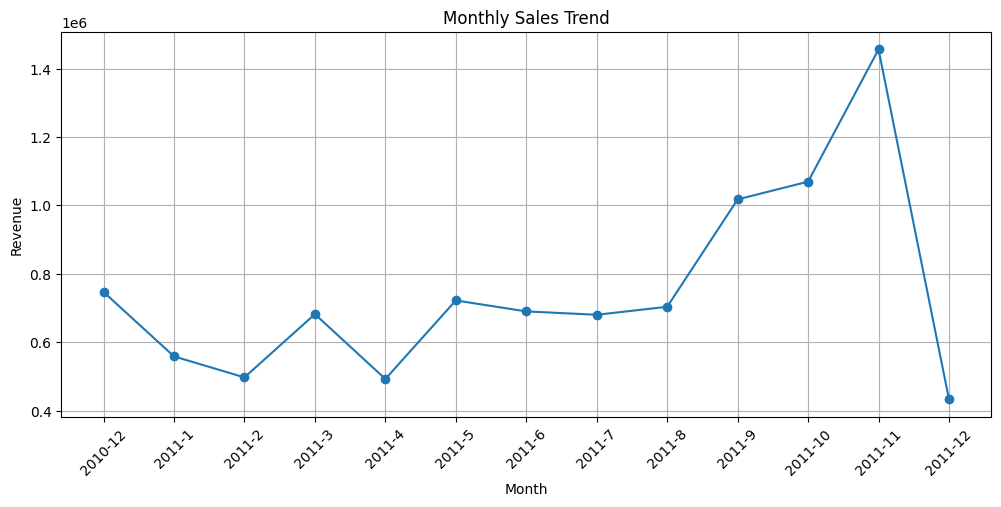

In [ ]:
import matplotlib.pyplot as plt

# Create Month-Year column
monthly_pd["Date"] = monthly_pd["Year"].astype(str) + "-" + monthly_pd["Month"].astype(str)

# Plot
plt.figure(figsize=(12,5))
plt.plot(monthly_pd["Date"], monthly_pd["Monthly_Revenue"], marker="o")

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Sales Trend")
plt.grid(True)
plt.show()